In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

pd.set_option("display.max_columns", 100)
sns.set_style("whitegrid")

In [9]:
noteevents = pd.read_csv(
    "../datasets/NOTEEVENTS_sorted.csv",
    usecols=[
        "SUBJECT_ID",
        "HADM_ID",
        "CATEGORY",
        "CHARTDATE",
        "TEXT"
    ],
    low_memory=False
)

admissions = pd.read_csv(
    "../datasets/ADMISSIONS_sorted.csv",
    usecols=[
        "SUBJECT_ID",
        "HADM_ID",
        "ADMISSION_TYPE",
        "DIAGNOSIS",
        "HOSPITAL_EXPIRE_FLAG"
    ]
)

diagnoses = pd.read_csv(
    "../datasets/DIAGNOSES_ICD_sorted.csv",
    usecols=[
        "SUBJECT_ID",
        "HADM_ID",
        "ICD9_CODE",
        "SEQ_NUM"
    ]
)

print("NOTEEVENTS shape:", noteevents.shape)
print("ADMISSIONS shape:", admissions.shape)
print("DIAGNOSES shape:", diagnoses.shape)

NOTEEVENTS shape: (482770, 5)
ADMISSIONS shape: (12911, 5)
DIAGNOSES shape: (118300, 4)


In [10]:
print("\n=== Missing Values ===\n")

for name, df in {
    "NOTEEVENTS": noteevents,
    "ADMISSIONS": admissions,
    "DIAGNOSES": diagnoses
}.items():

    print(f"\n{name}")
    print(df.isnull().sum())


=== Missing Values ===


NOTEEVENTS
SUBJECT_ID        0
HADM_ID       48303
CHARTDATE         0
CATEGORY          0
TEXT              0
dtype: int64

ADMISSIONS
SUBJECT_ID              0
HADM_ID                 0
ADMISSION_TYPE          0
DIAGNOSIS               8
HOSPITAL_EXPIRE_FLAG    0
dtype: int64

DIAGNOSES
SUBJECT_ID     0
HADM_ID        0
SEQ_NUM       13
ICD9_CODE     13
dtype: int64


In [11]:
print("\n=== Note Categories ===\n")

category_counts = (
    noteevents["CATEGORY"]
    .value_counts()
)

print(category_counts.head(20))


=== Note Categories ===

CATEGORY
Nursing/other        291802
Radiology            104995
ECG                   43631
Discharge summary     13063
Nursing               10268
Echo                   9174
Physician              7407
Respiratory            1290
General                 440
Nutrition               383
Social Work             126
Rehab Services          119
Case Management          67
Pharmacy                  3
Consult                   2
Name: count, dtype: int64


In [12]:
notes = (
    noteevents[
        noteevents["CATEGORY"] == "Discharge summary"
    ]
    .copy()
)

print("\n=== Discharge Summaries ===")
print(f"Rows: {len(notes):,}")
print(f"Unique patients: {notes['SUBJECT_ID'].nunique():,}")
print(f"Unique admissions: {notes['HADM_ID'].nunique():,}")



=== Discharge Summaries ===
Rows: 13,063
Unique patients: 8,367
Unique admissions: 11,061


In [13]:
notes["CHARTDATE"] = pd.to_datetime(
    notes["CHARTDATE"],
    errors="coerce"
)


notes = (
    notes
    .sort_values("CHARTDATE")
    .drop_duplicates(
        subset="HADM_ID",
        keep="last"
    )
    .reset_index(drop=True)
)

print("\n=== After Deduplication ===")
print(f"Rows: {len(notes):,}")


=== After Deduplication ===
Rows: 11,061


In [14]:
notes = notes.merge(
    admissions,
    on=["SUBJECT_ID", "HADM_ID"],
    how="left"
)

print("\nMerged notes shape:", notes.shape)


Merged notes shape: (11061, 8)


In [15]:
notes["char_length"] = notes["TEXT"].astype(str).apply(len)

notes["word_count"] = (
    notes["TEXT"]
    .astype(str)
    .apply(lambda x: len(x.split()))
)

print("\n=== Note Length Statistics ===\n")

print(
    notes[
        ["char_length", "word_count"]
    ].describe()
)



=== Note Length Statistics ===

        char_length    word_count
count  11061.000000  11061.000000
mean    8254.762228   1236.122322
std     4771.208878    721.379653
min      215.000000     21.000000
25%     5042.000000    747.000000
50%     7337.000000   1099.000000
75%    10599.000000   1592.000000
max    45149.000000   6602.000000


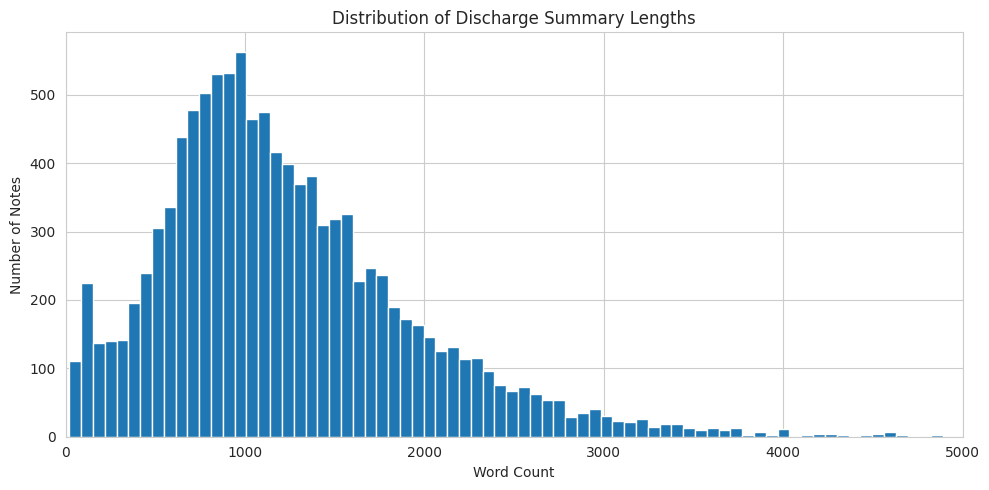

In [17]:
plt.figure(figsize=(10, 5))

plt.hist(
    notes["word_count"],
    bins=100
)

plt.xlim(0, 5000)

plt.xlabel("Word Count")
plt.ylabel("Number of Notes")
plt.title("Distribution of Discharge Summary Lengths")

plt.tight_layout()

plt.savefig(
    "../outputs/note_length_distribution.png",
    dpi=150
)

plt.show()

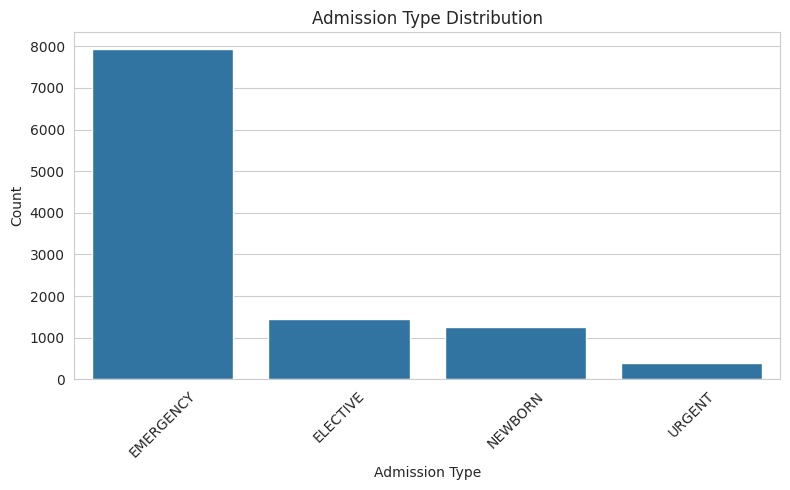

In [18]:
plt.figure(figsize=(8, 5))

admission_counts = (
    notes["ADMISSION_TYPE"]
    .value_counts()
)

sns.barplot(
    x=admission_counts.index,
    y=admission_counts.values
)

plt.xticks(rotation=45)

plt.xlabel("Admission Type")
plt.ylabel("Count")
plt.title("Admission Type Distribution")

plt.tight_layout()

plt.savefig(
    "../outputs/admission_type_distribution.png",
    dpi=150
)

plt.show()


=== Mortality Distribution ===

HOSPITAL_EXPIRE_FLAG
0.0    9867
1.0    1170
Name: count, dtype: int64


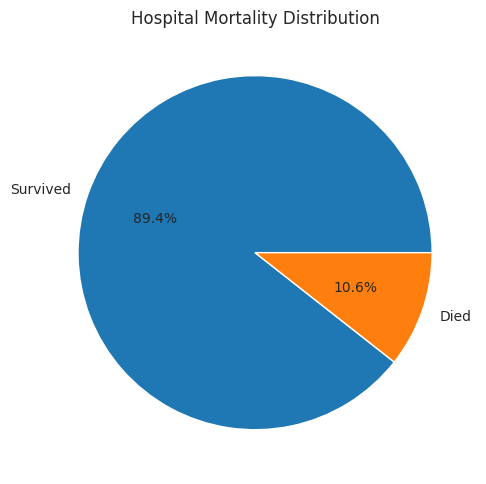

In [19]:
mortality_counts = (
    notes["HOSPITAL_EXPIRE_FLAG"]
    .value_counts()
)

print("\n=== Mortality Distribution ===\n")
print(mortality_counts)

plt.figure(figsize=(5, 5))

plt.pie(
    mortality_counts.values,
    labels=["Survived", "Died"],
    autopct="%1.1f%%"
)

plt.title("Hospital Mortality Distribution")

plt.tight_layout()

plt.savefig(
    "../outputs/mortality_distribution.png",
    dpi=150
)

plt.show()

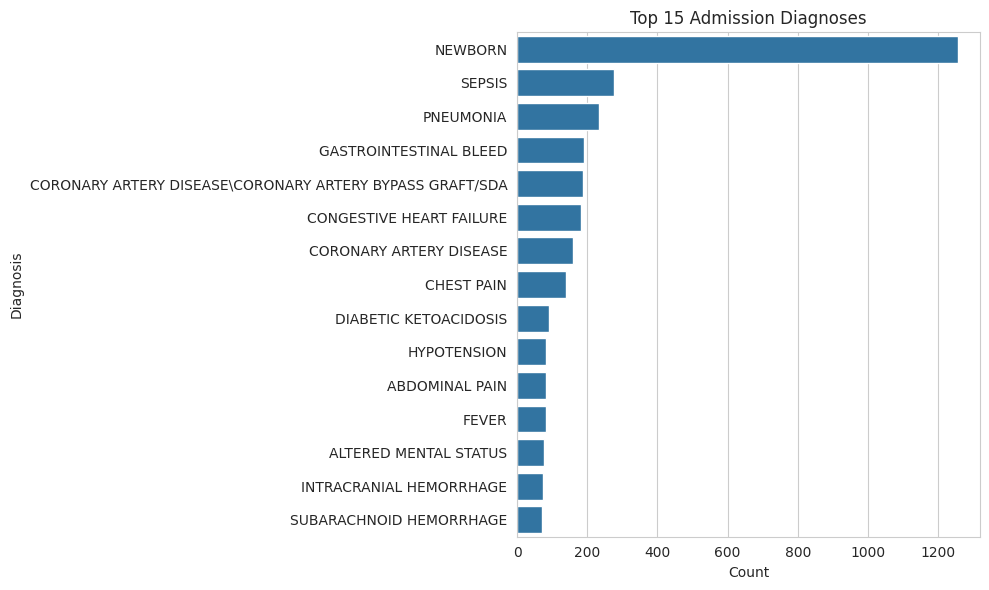

In [21]:
top_diag = (
    notes["DIAGNOSIS"]
    .value_counts()
    .head(15)
)

plt.figure(figsize=(10, 6))

sns.barplot(
    y=top_diag.index,
    x=top_diag.values
)

plt.xlabel("Count")
plt.ylabel("Diagnosis")
plt.title("Top 15 Admission Diagnoses")

plt.tight_layout()

plt.savefig(
    "../outputs/top_diagnoses.png",
    dpi=150
)

plt.show()

In [22]:
top_icd = (
    diagnoses["ICD9_CODE"]
    .value_counts()
    .head(20)
)

print("\n=== Top ICD-9 Codes ===\n")
print(top_icd)


=== Top ICD-9 Codes ===

ICD9_CODE
4019     3901
4280     2818
42731    2503
41401    2461
V053     1968
V290     1912
25000    1656
5849     1617
51881    1488
2720     1423
5990     1270
V3000    1211
486      1012
2859      928
V3001     922
53081     922
496       874
5070      826
2449      823
7742      814
Name: count, dtype: int64


In [23]:
print("\n=== Sample Notes ===\n")

sample_notes = notes.sample(3, random_state=42)

for idx, row in sample_notes.iterrows():

    print("=" * 80)

    print("HADM_ID:", row["HADM_ID"])
    print("Diagnosis:", row["DIAGNOSIS"])
    print("Admission Type:", row["ADMISSION_TYPE"])

    print("\nTEXT PREVIEW:\n")

    print(row["TEXT"][:2000])

    print("\n")


=== Sample Notes ===

HADM_ID: 110925.0
Diagnosis: ACUTE CORONARY SYNDROME
Admission Type: EMERGENCY

TEXT PREVIEW:

Admission Date: [**2114-4-17**]        Discharge Date: [**2114-4-26**]

Date of Birth:  [**2059-12-24**]        Sex:  F

Service:  CCU

CHIEF COMPLAINT:  The patient was admitted with the chief
complaint of shortness of breath.

HISTORY OF PRESENT ILLNESS:  The patient is a 50 year old
female with a history of breast cancer treated with surgery,
high dose chemotherapy (including Adriamycin), auto bone
marrow transplant and radiation, who has had other admissions
since her treatment. The patient had been doing well up until
approximately three weeks ago.  The patient developed a
nonproductive cough, denied any fevers, chills, pleuritic
chest pain and began to have episodes of shortness of breath.
The patient now reports being short of breath at
approximately angle of 20 degrees and could not lie flat at
night.  No chest pain, no diaphoresis, occasional hot
flashes, no na

In [24]:
phi_example = notes[
    notes["TEXT"].str.contains(r"\[\*\*", regex=True, na=False)
].iloc[0]["TEXT"]

print("\n=== PHI Placeholder Example ===\n")

print(phi_example[:1500])


=== PHI Placeholder Example ===

Name:  [**Known lastname 183**], [**Known firstname **] A           Unit No:  [**Numeric Identifier 17409**]

Admission Date: [**2100-7-11**]        Discharge Date: [**2100-7-15**]

Date of Birth:  [**2062-12-19**]        Sex:  F

Service:  [**Last Name (un) **]


ADDENDUM:  The patient had to spend last night ([**2100-7-12**]) because of unable to transport in the evening and
required dialysis during the day.  This morning, she is doing
well.  She was found asleep.  On examination, her abdomen was
soft, nontender, and nondistended.  She was afebrile.  She
was tolerating oral intake.  She was complaining of nausea,
but no vomiting.  She was able to eat regular meals (a full
meal).

CONDITION ON DISCHARGE:  Same.

DISCHARGE DISPOSITION:  The patient to be discharged back to
nursing facility today.



                        [**Name6 (MD) **] [**Name8 (MD) **], [**MD Number(1) 16979**]

Dictated By:[**Last Name (NamePattern1) 10534**]
MEDQUIST36
D:  [**2

In [26]:
eda_df = notes[
    [
        "SUBJECT_ID",
        "HADM_ID",
        "CHARTDATE",
        "ADMISSION_TYPE",
        "DIAGNOSIS",
        "HOSPITAL_EXPIRE_FLAG",
        "TEXT",
        "char_length",
        "word_count"
    ]
]

eda_df.to_csv(
    "../outputs/eda_base_dataset.csv",
    index=False
)

In [27]:
print("\n=== FINAL SUMMARY ===\n")

print(f"Final discharge summaries: {len(notes):,}")
print(f"Unique patients: {notes['SUBJECT_ID'].nunique():,}")
print(f"Mean word count: {notes['word_count'].mean():.1f}")
print(f"Median word count: {notes['word_count'].median():.1f}")


=== FINAL SUMMARY ===

Final discharge summaries: 11,061
Unique patients: 8,367
Mean word count: 1236.1
Median word count: 1099.0
